# Subsea-to-shore design with NeqSim and response surfaces

**Version 1.0.0 — companion to [NeqSim issue #4253](https://github.com/equinor/neqsim/issues/4253).**

Build a reproducible hydraulic screening study, compare Beggs–Brill and
TwoFluidPipe, learn a quadratic response surface, and replay its predictions
in the original simulator. A homogeneous AdiabaticPipe calculation provides
a third, deliberately simpler hydraulic comparison.

By the end you can define a composable pipe model, estimate the rate at a
receiving-pressure constraint, separate surrogate error from model disagreement,
check mesh sensitivity, and attach evidence to a NeqSim improvement issue.

**Evidence boundary:** all fluids and design cases below are synthetic.
There is no measured Ormen Lange or Brazilian field dataset in this notebook.
No comparison here establishes which multiphase model is more accurate.

## 1. What the paper supports

The [public ASME submission abstract](https://omae.secure-platform.com/a/solicitations/267/sessiongallery/23063/application/180942)
describes flow simulations varying fluid properties, pipe diameter and distance
to shore, followed by response-surface functions for production rate. Its author
list also includes Marcelo Igor Lourenço de Souza, absent from the automated issue.
The retrieved abstract supplies no numerical cases, coefficients, uncertainties
or downloadable measurement dataset. The notebook follows that **method**;
it does not reproduce the paper's numerical results.

We freeze current NeqSim master at
[1768fc1fec78ff974fe9ff4232582f09ed504686](https://github.com/equinor/neqsim/tree/1768fc1fec78ff974fe9ff4232582f09ed504686),
inspected on 7 October 2026. The Python package supplies the bridge, while all
Java calculations use the source-built JAR. Change the source revision only
after repeating execution, mesh checks and surrogate qualification.

[PipeBeggsAndBrills guide](https://github.com/equinor/neqsim/blob/1768fc1fec78ff974fe9ff4232582f09ed504686/docs/process/PipeBeggsAndBrills.md)
· [TwoFluidPipe model and limits](https://github.com/equinor/neqsim/blob/1768fc1fec78ff974fe9ff4232582f09ed504686/docs/process/TWOFLUIDPIPE_MODEL.md)
· [Existing full wellstream tutorial](wellstream_steady_dynamic_multiphase_master.ipynb)

In [1]:
import importlib.util
import os
import subprocess
import sys

required_modules = ["jpype", "numpy", "pandas", "matplotlib", "scipy", "sklearn"]
missing_modules = [
    name for name in required_modules if importlib.util.find_spec(name) is None
]
if missing_modules:
    packages = [
        "neqsim==3.23.0",
        "jpype1==1.7.1",
        "numpy==2.5.3",
        "pandas==3.0.6",
        "matplotlib==3.11.2",
        "scipy==1.18.1",
        "scikit-learn==1.9.1",
    ]
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages],
        check=True,
    )
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
print("Dependencies available. Java source provenance is checked next.")

Dependencies available. Java source provenance is checked next.


In [2]:
import hashlib
import json
import platform
import shutil
import time
from importlib.metadata import version
from pathlib import Path

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import brentq
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

NEQSIM_SOURCE_REF = "1768fc1fec78ff974fe9ff4232582f09ed504686"
source_root_override = os.environ.get("NEQSIM_SOURCE_ROOT")
source_root = Path(source_root_override or "/content/neqsim-4253-source").resolve()
if not source_root_override:
    source_root.mkdir(parents=True, exist_ok=True)
    if not (source_root / ".git").exists():
        subprocess.run(["git", "init", str(source_root)], check=True, capture_output=True)
        subprocess.run(
            [
                "git", "-C", str(source_root), "remote", "add", "origin",
                "https://github.com/equinor/neqsim.git",
            ],
            check=True,
            capture_output=True,
        )
    subprocess.run(
        ["git", "-C", str(source_root), "fetch", "--depth=1", "origin", NEQSIM_SOURCE_REF],
        check=True,
        capture_output=True,
    )
    subprocess.run(
        ["git", "-C", str(source_root), "checkout", "--detach", "FETCH_HEAD"],
        check=True,
        capture_output=True,
    )
    java_executable = Path(shutil.which("java")).resolve()
    build_environment = dict(os.environ)
    build_environment["JAVA_HOME"] = str(java_executable.parent.parent)
    subprocess.run(
        ["bash", "mvnw", "-q", "-Dmaven.test.skip=true", "-Dmaven.javadoc.skip=true", "package"],
        cwd=source_root,
        env=build_environment,
        check=True,
        capture_output=True,
    )

resolved_source_ref = subprocess.check_output(
    ["git", "-C", str(source_root), "rev-parse", "HEAD"],
    text=True,
).strip()
assert resolved_source_ref == NEQSIM_SOURCE_REF
jar_override = os.environ.get("NEQSIM_SOURCE_JAR")
source_jar = Path(jar_override or source_root / "target/neqsim-3.23.0.jar").resolve()
assert source_jar.is_file()
assert not jpype.isJVMStarted(), "Restart the runtime before changing the Java class path."
jpype.addClassPath(str(source_jar))
jpype.startJVM("-Xmx2g", convertStrings=True)
JClass = jpype.JClass
required_classes = [
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills",
    "neqsim.process.equipment.pipeline.TwoFluidPipe",
    "neqsim.process.equipment.pipeline.SteadyStateConvergenceReport",
]
for class_name in required_classes:
    location = JClass(class_name).class_.getProtectionDomain().getCodeSource().getLocation()
    assert Path(str(location.toURI().getPath())).resolve() == source_jar

provenance = {
    "source_repository": "equinor/neqsim",
    "source_ref": resolved_source_ref,
    "jar_sha256": hashlib.sha256(source_jar.read_bytes()).hexdigest(),
    "python": platform.python_version(),
    "java": str(JClass("java.lang.System").getProperty("java.version")),
    "packages": {
        name: version(name)
        for name in ["neqsim", "jpype1", "numpy", "pandas", "matplotlib", "scipy", "scikit-learn"]
    },
}
print(json.dumps(provenance, indent=2))
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
pd.set_option("display.max_columns", 12)

{
  "source_repository": "equinor/neqsim",
  "source_ref": "1768fc1fec78ff974fe9ff4232582f09ed504686",
  "jar_sha256": "c9ca3a016a9b1e524e53e22e2ff9bb0b8fc98ef629df566e261ec5a3c084f9c8",
  "python": "3.12.14",
  "java": "17.0.20",
  "packages": {
    "neqsim": "3.23.0",
    "jpype1": "1.7.1",
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2",
    "scipy": "1.18.1",
    "scikit-learn": "1.9.1"
  }
}


## 2. Engineering question and assumptions

What **hydraulic screening rate** reaches an onshore receiver at 80 bara from
a 100 bara inlet? The inlet temperature is 40 °C; roughness is 45 µm.
We vary inner diameter (0.25–0.45 m), horizontal length (20–60 km), and
decane mole fraction (0.02–0.10) in methane. Composition sums to one.
SRK with the classic mixing rule and multiphase checking provides the fluid.

The main comparison is **isothermal**, with no elevation change or terrain
tracking. This isolates hydraulic/model and surrogate effects. It excludes
seabed heat loss, shore rise, reservoir deliverability, equipment capacity,
hydrate/wax margins, erosion and transient slugging. It is not the maximum
safe production rate of a complete field. AdiabaticPipe is given the same
outlet temperature as a fixed-temperature homogeneous diagnostic; its name
does not imply an adiabatic energy balance in this experiment.

The pressure condition is $P_{\mathrm{out}}(\dot m,D,L,z_d)=80\ \mathrm{bara}$.
Here $\dot m$ is mass rate in kg/s, $D$ is inner diameter in m, $L$ is length
in m and $z_d$ is decane mole fraction. A fresh stream and pipe are built
for each evaluation, so candidates never share mutable state.

In [3]:
inlet_pressure_bara = 100.0
inlet_temperature_c = 40.0
receiver_pressure_bara = 80.0
roughness_m = 4.5e-5
default_sections = 30
pressure_tolerance_bar = 0.02
model_names = ["PipeBeggsAndBrills", "TwoFluidPipe", "AdiabaticPipe"]
base_design = {"diameter_m": 0.35, "length_km": 40.0, "decane_mol_fraction": 0.06}
design_bounds = np.array([[0.25, 0.45], [20.0, 60.0], [0.02, 0.10]])
feature_names = ["diameter_m", "length_km", "decane_mol_fraction"]

def make_inlet(decane_fraction, mass_rate_kg_s, component=None):
    fluid = JClass("neqsim.thermo.system.SystemSrkEos")(
        inlet_temperature_c + 273.15,
        inlet_pressure_bara,
    )
    if component is None:
        fluid.addComponent("methane", 1.0 - decane_fraction)
        fluid.addComponent("nC10", decane_fraction)
    else:
        fluid.addComponent(component, 1.0)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    inlet = JClass("neqsim.process.equipment.stream.Stream")("subsea feed", fluid)
    inlet.setFlowRate(float(mass_rate_kg_s), "kg/sec")
    inlet.run()
    inlet.getFluid().initProperties()
    return inlet

def build_pipe(model_name, inlet, design, sections=default_sections):
    pipe = JClass("neqsim.process.equipment.pipeline." + model_name)(
        model_name + " export line",
        inlet,
    )
    pipe.setLength(float(design["length_km"] * 1000.0))
    pipe.setDiameter(float(design["diameter_m"]))
    if model_name == "TwoFluidPipe":
        pipe.setRoughness(roughness_m)
        pipe.setNumberOfSections(int(sections))
        elevations = jpype.JArray(jpype.JDouble)([0.0] * (sections + 1))
        pipe.setElevationProfile(elevations)
        pipe.setEnableTerrainTracking(False)
        pipe.setHeatTransferCoefficient(0.0)
        pipe.setEnableJouleThomson(False)
    else:
        pipe.setPipeWallRoughness(roughness_m)
    if model_name == "PipeBeggsAndBrills":
        pipe.setNumberOfIncrements(int(sections))
        thermal_mode = JClass(
            "neqsim.process.equipment.pipeline.PipeBeggsAndBrills$HeatTransferMode"
        )
        pipe.setHeatTransferMode(thermal_mode.ISOTHERMAL)
    if model_name == "AdiabaticPipe":
        pipe.setOutletTemperature(inlet_temperature_c + 273.15)
    return pipe

def evaluate_pipe(model_name, design, mass_rate_kg_s, sections=default_sections):
    started = time.perf_counter()
    inlet = make_inlet(design["decane_mol_fraction"], mass_rate_kg_s)
    pipe = build_pipe(model_name, inlet, design, sections)
    process = JClass("neqsim.process.processmodel.ProcessSystem")()
    process.add(inlet)
    process.add(pipe)
    process.run()
    outlet = pipe.getOutletStream()
    outlet.getFluid().initProperties()
    row = {
        "model": model_name,
        **design,
        "rate_kg_s": float(mass_rate_kg_s),
        "outlet_bara": float(outlet.getPressure("bara")),
        "outlet_temperature_c": float(outlet.getTemperature("C")),
        "mass_balance_relative": abs(
            outlet.getFlowRate("kg/sec") - inlet.getFlowRate("kg/sec")
        ) / mass_rate_kg_s,
        "inlet_phases": int(inlet.getFluid().getNumberOfPhases()),
        "seconds": time.perf_counter() - started,
        "converged": True,
        "termination": "FORWARD_CALCULATION",
    }
    if model_name == "TwoFluidPipe":
        report = pipe.getSteadyStateConvergenceReport()
        row.update({
            "converged": bool(report.isConverged()),
            "termination": str(report.getTerminationReason()),
            "iterations": int(report.getIterations()),
            "mass_flux_residual": float(report.getMassFluxResidual()),
            "pressure_momentum_residual": float(report.getPressureMomentumResidual()),
            "liquid_holdup": float(pipe.getAverageLiquidHoldup()),
        })
    elif model_name == "PipeBeggsAndBrills":
        holdup = np.array(pipe.getLiquidHoldupProfile(), dtype=float)
        row["liquid_holdup"] = float(holdup.mean())
    if not row["converged"]:
        raise RuntimeError(f"Rejected {model_name} candidate: {row['termination']}")
    assert np.isfinite(row["outlet_bara"]) and row["outlet_bara"] > 1.0
    assert row["mass_balance_relative"] < 1e-9
    assert abs(row["outlet_temperature_c"] - inlet_temperature_c) < 1e-6
    return row, {"inlet": inlet, "pipe": pipe, "outlet": outlet, "process": process}

sample_rows = []
sample_models = {}
for model_name in model_names:
    result, objects = evaluate_pipe(model_name, base_design, 30.0)
    sample_rows.append(result)
    sample_models[model_name] = objects
display(pd.DataFrame(sample_rows)[
    [
        "model", "rate_kg_s", "outlet_bara", "liquid_holdup",
        "mass_balance_relative", "termination",
    ]
].rename(columns={
    "mass_balance_relative": "mass_error",
    "liquid_holdup": "holdup",
}).round(6))

,model,rate_kg_s,outlet_bara,holdup,mass_error,termination
0,PipeBeggsAndBrills,30.0,89.602212,0.207207,0.0,FORWARD_CALCULATION
1,TwoFluidPipe,30.0,91.559082,0.106533,0.0,CONVERGED
2,AdiabaticPipe,30.0,95.931953,NaN,0.0,FORWARD_CALCULATION


## 3. Solve the receiving-pressure constraint

The outer root solver stops only when a **replayed, converged** pipe satisfies
the receiving pressure to 0.02 bar. Its bracket is estimated from a low-rate
pressure drop, and checked explicitly. Unconverged TwoFluidPipe states and
unclassified Java exceptions stop the calculation; they never enter training.
The root solver deliberately does not use Beggs–Brill's built-in flow mode
because the iteration-limit defect is reproduced in section 8.

A root is a local hydraulic rate within these assumptions. Monotonicity and
nearby-point checks below qualify its use in this bounded design box.

In [4]:
def solve_hydraulic_rate(model_name, design, sections=default_sections):
    low_rate = 2.0
    low_result, _ = evaluate_pipe(model_name, design, low_rate, sections)
    low_drop = inlet_pressure_bara - low_result["outlet_bara"]
    target_drop = inlet_pressure_bara - receiver_pressure_bara
    assert 0.0 < low_drop < target_drop
    high_rate = low_rate * np.sqrt(target_drop / low_drop) * 1.08
    evaluations = []

    def pressure_residual(rate):
        result, _ = evaluate_pipe(model_name, design, rate, sections)
        evaluations.append(result)
        return result["outlet_bara"] - receiver_pressure_bara

    low_residual = pressure_residual(low_rate)
    high_residual = pressure_residual(high_rate)
    expansion_count = 0
    while high_residual > 0.0 and expansion_count < 8:
        high_rate *= 1.15
        high_residual = pressure_residual(high_rate)
        expansion_count += 1
    assert low_residual > 0.0 and high_residual < 0.0, "Unqualified root bracket"
    rate = brentq(
        pressure_residual,
        low_rate,
        high_rate,
        xtol=1e-4,
        rtol=1e-6,
        maxiter=40,
    )
    final, objects = evaluate_pipe(model_name, design, rate, sections)
    final["pressure_residual_bar"] = final["outlet_bara"] - receiver_pressure_bara
    final["outer_evaluations"] = len(evaluations) + 2
    assert abs(final["pressure_residual_bar"]) <= pressure_tolerance_bar
    assert final["inlet_phases"] == 2
    return final, objects

baseline_rows = []
baseline_objects = {}
for model_name in model_names:
    row, objects = solve_hydraulic_rate(model_name, base_design)
    baseline_rows.append(row)
    baseline_objects[model_name] = objects
baseline = pd.DataFrame(baseline_rows)
display(baseline[
    ["model", "rate_kg_s", "outlet_bara", "liquid_holdup", "outer_evaluations"]
].round(5))

,model,rate_kg_s,outlet_bara,liquid_holdup,outer_evaluations
0,PipeBeggsAndBrills,40.38349,79.99999,0.17776,11
1,TwoFluidPipe,44.04026,80.00000,0.09986,12
2,AdiabaticPipe,63.70336,80.00000,NaN,11


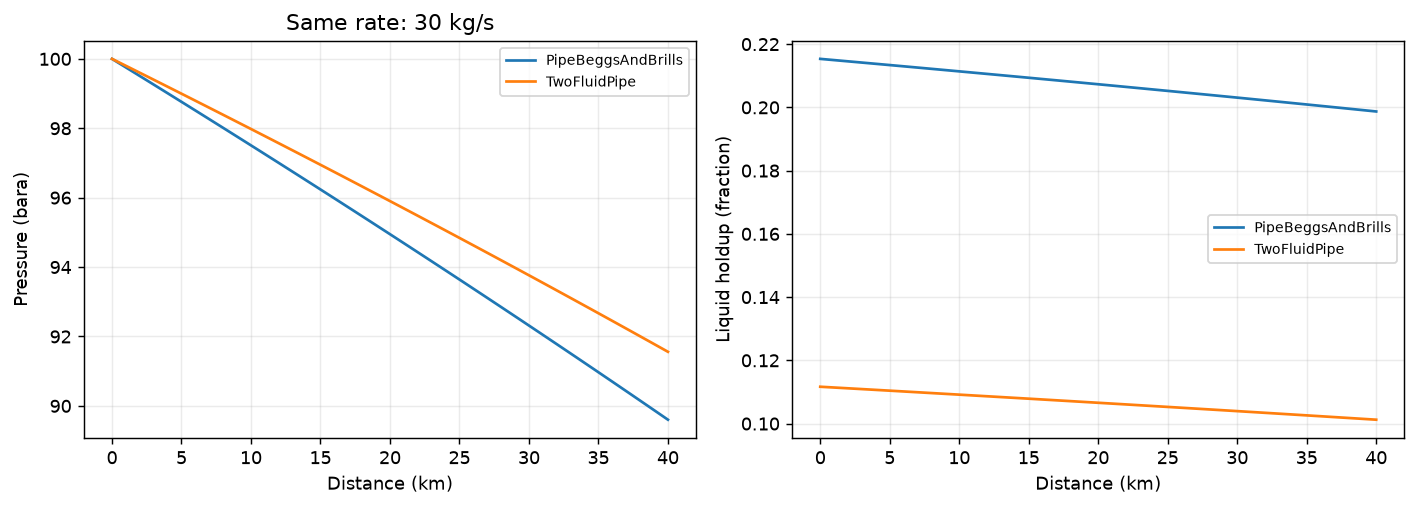

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for model_name in model_names[:2]:
    pipe = sample_models[model_name]["pipe"]
    pressures = np.array(pipe.getPressureProfile(), dtype=float)
    holdups = np.array(pipe.getLiquidHoldupProfile(), dtype=float)
    if model_name == "TwoFluidPipe":
        pressures /= 1e5
    distance_km = np.linspace(0.0, base_design["length_km"], len(pressures))
    holdup_distance_km = np.linspace(0.0, base_design["length_km"], len(holdups))
    axes[0].plot(distance_km, pressures, label=model_name)
    axes[1].plot(holdup_distance_km, holdups, label=model_name)
axes[0].set(xlabel="Distance (km)", ylabel="Pressure (bara)", title="Same rate: 30 kg/s")
axes[1].set(xlabel="Distance (km)", ylabel="Liquid holdup (fraction)")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Validation before machine learning

Three separate checks are used: a single-liquid Darcy–Weisbach reference,
numerical mesh refinement, and nearby operating/design trends.
The analytical reference uses NeqSim liquid density and viscosity and an
independently evaluated Colebrook friction factor. It checks hydraulics
and units; it is not independent validation of SRK liquid properties.

$$\Delta P=f_D\frac{L}{D}\frac{\rho v^2}{2}$$

$\Delta P$ is pressure loss in Pa, $f_D$ is the Darcy friction factor,
$\rho$ is liquid density in kg/m³ and $v$ is bulk velocity in m/s.
This single-phase check cannot validate multiphase holdup or slip.

In [6]:
liquid_design = {"diameter_m": 0.25, "length_km": 1.0, "decane_mol_fraction": 1.0}
liquid_rate_kg_s = 10.0
liquid_inlet = make_inlet(1.0, liquid_rate_kg_s, component="nC10")
liquid_fluid = liquid_inlet.getFluid()
assert liquid_fluid.getNumberOfPhases() == 1
density_kg_m3 = float(liquid_fluid.getDensity("kg/m3"))
viscosity_pa_s = float(liquid_fluid.getViscosity("kg/msec"))
area_m2 = np.pi * liquid_design["diameter_m"] ** 2 / 4.0
velocity_m_s = liquid_rate_kg_s / density_kg_m3 / area_m2
reynolds = density_kg_m3 * velocity_m_s * liquid_design["diameter_m"] / viscosity_pa_s

def colebrook_residual(darcy_factor):
    return 1.0 / np.sqrt(darcy_factor) + 2.0 * np.log10(
        roughness_m / (3.7 * liquid_design["diameter_m"])
        + 2.51 / (reynolds * np.sqrt(darcy_factor))
    )

darcy_factor = brentq(colebrook_residual, 0.005, 0.1)
reference_drop_bar = (
    darcy_factor
    * liquid_design["length_km"] * 1000.0 / liquid_design["diameter_m"]
    * density_kg_m3 * velocity_m_s ** 2 / 2.0 / 1e5
)
analytical_rows = []
for model_name in model_names:
    pipe = build_pipe(model_name, liquid_inlet, liquid_design, sections=60)
    pipe.run()
    calculated_drop_bar = inlet_pressure_bara - pipe.getOutletStream().getPressure("bara")
    analytical_rows.append({
        "model": model_name,
        "drop_bar": calculated_drop_bar,
        "Darcy_reference_bar": reference_drop_bar,
        "relative_difference_pct": 100.0 * (
            calculated_drop_bar / reference_drop_bar - 1.0
        ),
    })
analytical = pd.DataFrame(analytical_rows)
display(analytical.round(6))
assert (analytical["relative_difference_pct"].abs() < 15.0).all()
print(f"Single-liquid hydraulic check passed; Reynolds number = {reynolds:,.0f}.")

Single-liquid hydraulic check passed; Reynolds number = 40,336.


,model,drop_bar,Darcy_reference_bar,relative_difference_pct
0,PipeBeggsAndBrills,0.024578,0.024895,-1.274652
1,TwoFluidPipe,0.024179,0.024895,-2.874175
2,AdiabaticPipe,0.025792,0.024895,3.605134


In [7]:
mesh_rows = []
for model_name in model_names[:2]:
    for sections in [15, 30, 60]:
        row, _ = solve_hydraulic_rate(model_name, base_design, sections)
        row["sections"] = sections
        mesh_rows.append(row)
mesh = pd.DataFrame(mesh_rows)
mesh["rate_difference_from_60_pct"] = np.nan
for model_name in model_names[:2]:
    selected = mesh["model"] == model_name
    fine_rate = mesh.loc[selected & (mesh["sections"] == 60), "rate_kg_s"].iloc[0]
    mesh.loc[selected, "rate_difference_from_60_pct"] = 100.0 * (
        mesh.loc[selected, "rate_kg_s"] / fine_rate - 1.0
    )
display(mesh[
    ["model", "sections", "rate_kg_s", "rate_difference_from_60_pct", "termination"]
].round(5))
nominal_mesh = mesh[mesh["sections"] == default_sections]
assert (nominal_mesh["rate_difference_from_60_pct"].abs() < 3.0).all()

trend_rows = []
for model_name in model_names[:2]:
    for multiplier in [0.95, 1.0, 1.05]:
        reference_rate = baseline.loc[baseline["model"] == model_name, "rate_kg_s"].iloc[0]
        row, _ = evaluate_pipe(model_name, base_design, reference_rate * multiplier)
        trend_rows.append(row)
nearby_rates = pd.DataFrame(trend_rows)
for model_name in model_names[:2]:
    pressures = nearby_rates.loc[nearby_rates["model"] == model_name, "outlet_bara"]
    assert np.all(np.diff(pressures) < 0.0)
display(nearby_rates[["model", "rate_kg_s", "outlet_bara"]].round(5))

,model,sections,rate_kg_s,rate_difference_from_60_pct,termination
0,PipeBeggsAndBrills,15,40.46091,0.28802,FORWARD_CALCULATION
1,PipeBeggsAndBrills,30,40.38349,0.09612,FORWARD_CALCULATION
2,PipeBeggsAndBrills,60,40.34471,0.00000,FORWARD_CALCULATION
3,TwoFluidPipe,15,44.93642,3.04002,CONVERGED
4,TwoFluidPipe,30,44.04026,0.98509,CONVERGED
5,TwoFluidPipe,60,43.61065,0.00000,CONVERGED


,model,rate_kg_s,outlet_bara
0,PipeBeggsAndBrills,38.36432,82.22346
1,PipeBeggsAndBrills,40.38349,79.99999
2,PipeBeggsAndBrills,42.40267,77.57247
3,TwoFluidPipe,41.83824,82.17983
4,TwoFluidPipe,44.04026,80.00000
5,TwoFluidPipe,46.24227,77.63716


## 5. Design of experiments

A 27-case three-level full factorial design trains each multiphase model's
surrogate. Sixteen seeded, off-grid designs are reserved for testing and
never used in fitting. Every target is an independently solved hydraulic rate.
Full tables are displayed and exported. The two models use identical fluid
and geometry inputs; their separate targets expose model disagreement.

In [8]:
from itertools import product

training_designs = pd.DataFrame(
    list(product([0.25, 0.35, 0.45], [20.0, 40.0, 60.0], [0.02, 0.06, 0.10])),
    columns=feature_names,
)
random_generator = np.random.default_rng(4253)
test_designs = pd.DataFrame(
    random_generator.uniform(design_bounds[:, 0], design_bounds[:, 1], size=(16, 3)),
    columns=feature_names,
)
sweep_rows = []
sweep_started = time.perf_counter()
for split_name, designs in [("train", training_designs), ("test", test_designs)]:
    for case_number, design_series in designs.iterrows():
        design = design_series.to_dict()
        for model_name in model_names[:2]:
            row, _ = solve_hydraulic_rate(model_name, design)
            row.update({"split": split_name, "case_id": f"{split_name}-{case_number:02d}"})
            sweep_rows.append(row)
    print(f"{split_name}: {len(designs)} designs completed for both multiphase models.")
sweep = pd.DataFrame(sweep_rows)
sweep_seconds = time.perf_counter() - sweep_started
assert len(sweep) == 86
assert sweep["converged"].all()
assert sweep["pressure_residual_bar"].abs().max() <= pressure_tolerance_bar
print(f"86 accepted hydraulic-rate roots in {sweep_seconds:.1f} s.")
with pd.option_context("display.max_rows", 100):
    display(sweep[
        ["case_id", "model", *feature_names, "rate_kg_s", "liquid_holdup", "termination"]
    ].round(5))

train: 27 designs completed for both multiphase models.
test: 16 designs completed for both multiphase models.
86 accepted hydraulic-rate roots in 132.3 s.


,case_id,model,diameter_m,length_km,decane_mol_fraction,rate_kg_s,liquid_holdup,termination
0,train-00,PipeBeggsAndBrills,0.25000,20.00000,0.02000,21.06935,0.10680,FORWARD_CALCULATION
1,train-00,TwoFluidPipe,0.25000,20.00000,0.02000,24.21852,0.03279,CONVERGED
2,train-01,PipeBeggsAndBrills,0.25000,20.00000,0.06000,23.71270,0.16755,FORWARD_CALCULATION
3,train-01,TwoFluidPipe,0.25000,20.00000,0.06000,25.99392,0.09986,CONVERGED
4,train-02,PipeBeggsAndBrills,0.25000,20.00000,0.10000,26.46152,0.22487,FORWARD_CALCULATION
5,train-02,TwoFluidPipe,0.25000,20.00000,0.10000,30.54039,0.16709,CONVERGED
6,train-03,PipeBeggsAndBrills,0.25000,40.00000,0.02000,14.89303,0.11342,FORWARD_CALCULATION
7,train-03,TwoFluidPipe,0.25000,40.00000,0.02000,17.06881,0.03267,CONVERGED
8,train-04,PipeBeggsAndBrills,0.25000,40.00000,0.06000,16.82224,0.18040,FORWARD_CALCULATION
9,train-04,TwoFluidPipe,0.25000,40.00000,0.06000,18.32982,0.09986,CONVERGED


## 6. Quadratic and physics-informed response surfaces

The ordinary RSM uses scaled diameter, length and composition. Its ten
coefficients include an intercept, three linear effects, three squared
effects and three pair interactions.

$$\hat y=b_0+\sum_{i=1}^{3}b_i x_i+\sum_{i=1}^{3}b_{ii}x_i^2+\sum_{i<j}b_{ij}x_i x_j$$

$\hat y$ is estimated rate in kg/s for the ordinary model; the dimensionless
$x_i$ are standardized design inputs. Coefficients use that specific scaling.

A second surrogate retains the turbulent Darcy scaling
$\dot m\propto D^{5/2}L^{-1/2}$ and fits a quadratic multiplicative correction.
This is a physics-informed baseline, not a calibrated experimental hybrid.
It uses the same ten-feature design and the same training data.

$$\hat{\dot m}=1\ \mathrm{kg\,s^{-1}}\,s(D,L)\exp(\hat y),\quad s(D,L)=\left(\frac{D}{0.35\ \mathrm m}\right)^{5/2}\left(\frac{L}{40\ \mathrm{km}}\right)^{-1/2}$$

For this second fit the target is $\ln\left[\frac{\dot m}{s\cdot 1\ \mathrm{kg\,s^{-1}}}\right]$.
The final numerical rate is reported in kg/s. The scaling does not model
changing friction factor, phase density, regime or holdup by itself.

In [9]:
def hydraulic_scaling(designs):
    values = np.asarray(designs, dtype=float)
    return (values[:, 0] / 0.35) ** 2.5 * (values[:, 1] / 40.0) ** -0.5

surrogate_models = {}
metric_rows = []
prediction_rows = []
coefficient_rows = []
for model_name in model_names[:2]:
    training = sweep[(sweep["model"] == model_name) & (sweep["split"] == "train")]
    testing = sweep[(sweep["model"] == model_name) & (sweep["split"] == "test")]
    scaler = StandardScaler().fit(training[feature_names])
    polynomial = PolynomialFeatures(degree=2, include_bias=True)
    train_features = polynomial.fit_transform(scaler.transform(training[feature_names]))
    test_features = polynomial.transform(scaler.transform(testing[feature_names]))
    rates = training["rate_kg_s"].to_numpy()
    ordinary = LinearRegression(fit_intercept=False).fit(train_features, rates)
    transformed_target = np.log(rates / hydraulic_scaling(training[feature_names]))
    physical = LinearRegression(fit_intercept=False).fit(train_features, transformed_target)
    surrogate_models[model_name] = {
        "scaler": scaler,
        "polynomial": polynomial,
        "ordinary": ordinary,
        "physical": physical,
    }
    predictions = {
        "quadratic": ordinary.predict(test_features),
        "physics-informed": hydraulic_scaling(testing[feature_names])
        * np.exp(physical.predict(test_features)),
    }
    actual = testing["rate_kg_s"].to_numpy()
    for surrogate_name, predicted in predictions.items():
        relative_error = (predicted - actual) / actual
        metric_rows.append({
            "model": model_name,
            "surrogate": surrogate_name,
            "MAE_kg_s": np.mean(np.abs(predicted - actual)),
            "MAPE_pct": 100.0 * np.mean(np.abs(relative_error)),
            "max_relative_error_pct": 100.0 * np.max(np.abs(relative_error)),
            "minimum_prediction_kg_s": predicted.min(),
        })
        for case_id, reference, estimate in zip(testing["case_id"], actual, predicted):
            prediction_rows.append({
                "model": model_name,
                "surrogate": surrogate_name,
                "case_id": case_id,
                "NeqSim_kg_s": reference,
                "predicted_kg_s": estimate,
                "relative_error_pct": 100.0 * (estimate / reference - 1.0),
            })
    terms = polynomial.get_feature_names_out(["diameter", "length", "decane"])
    for term, ordinary_coef, physical_coef in zip(terms, ordinary.coef_, physical.coef_):
        coefficient_rows.append({
            "model": model_name,
            "standardized_term": term,
            "quadratic_coefficient": ordinary_coef,
            "physical_log_coefficient": physical_coef,
        })
metrics = pd.DataFrame(metric_rows)
predictions = pd.DataFrame(prediction_rows)
coefficients = pd.DataFrame(coefficient_rows)
display(metrics.rename(columns={
    "MAE_kg_s": "MAE (kg/s)",
    "MAPE_pct": "MAPE (%)",
    "max_relative_error_pct": "worst (%)",
    "minimum_prediction_kg_s": "min rate (kg/s)",
}).round(5))
display(coefficients.round(6))
physical_metrics = metrics[metrics["surrogate"] == "physics-informed"]
qualified_models = dict(zip(
    physical_metrics["model"],
    physical_metrics["max_relative_error_pct"] <= 5.0,
))
print("Held-out 5% screening gate:", qualified_models)

Held-out 5% screening gate: {'PipeBeggsAndBrills': True, 'TwoFluidPipe': True}


,model,surrogate,MAE (kg/s),MAPE (%),worst (%),min rate (kg/s)
0,PipeBeggsAndBrills,quadratic,1.21847,3.84309,11.65156,15.13435
1,PipeBeggsAndBrills,physics-informed,0.09960,0.21382,0.52200,13.96795
2,TwoFluidPipe,quadratic,1.60506,4.76694,15.03809,16.53047
3,TwoFluidPipe,physics-informed,0.28393,0.73624,2.16541,15.30231


,model,standardized_term,quadratic_coefficient,physical_log_coefficient
0,PipeBeggsAndBrills,1,40.014864,3.698159
1,PipeBeggsAndBrills,diameter,26.707070,0.024483
2,PipeBeggsAndBrills,length,-10.935492,0.000622
3,PipeBeggsAndBrills,decane,4.463774,0.092233
4,PipeBeggsAndBrills,diameter^2,4.903497,-0.003234
5,PipeBeggsAndBrills,diameter length,-6.044699,-0.000174
6,PipeBeggsAndBrills,diameter decane,2.483918,0.000606
7,PipeBeggsAndBrills,length^2,3.466900,0.000541
8,PipeBeggsAndBrills,length decane,-1.055849,-0.000988
9,PipeBeggsAndBrills,decane^2,-0.038597,-0.005503


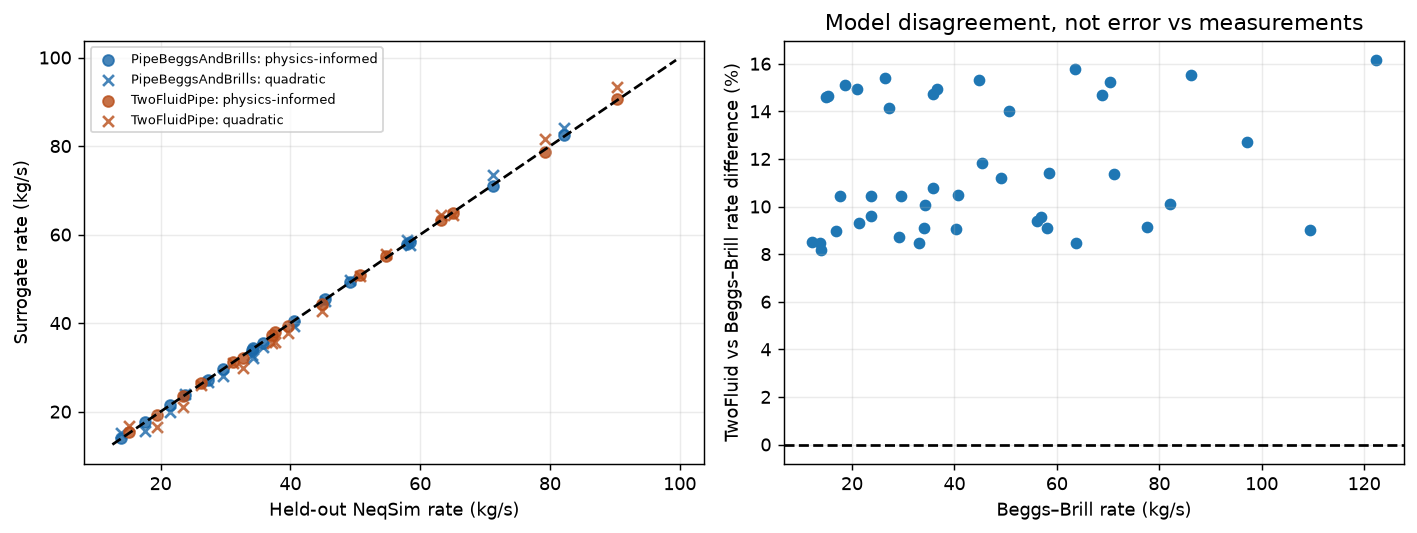

model,PipeBeggsAndBrills,TwoFluidPipe,TwoFluid_minus_BB_pct
min,12.2170,13.2552,8.1782
mean,45.2971,50.6854,11.6142
max,122.2822,142.0365,16.1546


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {"PipeBeggsAndBrills": "#1967a8", "TwoFluidPipe": "#b84d19"}
for (model_name, surrogate_name), selected in predictions.groupby(["model", "surrogate"]):
    marker = "o" if surrogate_name == "physics-informed" else "x"
    axes[0].scatter(
        selected["NeqSim_kg_s"],
        selected["predicted_kg_s"],
        c=colors[model_name],
        marker=marker,
        label=f"{model_name}: {surrogate_name}",
        alpha=0.8,
    )
minimum_rate = predictions["NeqSim_kg_s"].min() * 0.9
maximum_rate = predictions["NeqSim_kg_s"].max() * 1.1
axes[0].plot([minimum_rate, maximum_rate], [minimum_rate, maximum_rate], "k--")
axes[0].set(xlabel="Held-out NeqSim rate (kg/s)", ylabel="Surrogate rate (kg/s)")
axes[0].legend(fontsize=7)
paired = sweep.pivot(
    index=["split", "case_id"], columns="model", values="rate_kg_s"
).reset_index()
paired["TwoFluid_minus_BB_pct"] = 100.0 * (
    paired["TwoFluidPipe"] / paired["PipeBeggsAndBrills"] - 1.0
)
axes[1].scatter(paired["PipeBeggsAndBrills"], paired["TwoFluid_minus_BB_pct"], s=30)
axes[1].axhline(0.0, color="black", linestyle="--")
axes[1].set(
    xlabel="Beggs–Brill rate (kg/s)",
    ylabel="TwoFluid vs Beggs–Brill rate difference (%)",
    title="Model disagreement, not error vs measurements",
)
for axis in axes:
    axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()
display(paired.describe().loc[
    ["min", "mean", "max"],
    ["PipeBeggsAndBrills", "TwoFluidPipe", "TwoFluid_minus_BB_pct"],
].round(4))

## 7. Use the surrogate only inside its qualified domain

Bounds and a held-out error gate screen every request. An out-of-box point
returns to NeqSim; a surrogate model that fails the 5% held-out gate also
returns to NeqSim. Accepted predictions are labelled as estimates.
Final engineering decisions replay the original simulator.

The 5% gate is a finite-test screening criterion, not a probabilistic bound
throughout the domain. Smooth interpolation can still miss a flow-regime
change. The existing NeqSim SurrogateModelRegistry already supplies a
fallback framework; a production adapter should carry these domain,
revision and qualification checks into that framework.

,model,case,route,estimated_rate_kg_s,replayed_outlet_bara,receiving_pressure_margin_bar
0,PipeBeggsAndBrills,inside domain,SURROGATE_ESTIMATE,40.37292,80.01215,0.01215
1,PipeBeggsAndBrills,outside domain,NEQSIM_FALLBACK,91.74883,80.00000,-0.00000
2,TwoFluidPipe,inside domain,SURROGATE_ESTIMATE,44.30086,79.73028,-0.26972
3,TwoFluidPipe,outside domain,NEQSIM_FALLBACK,100.15055,80.00000,0.00000


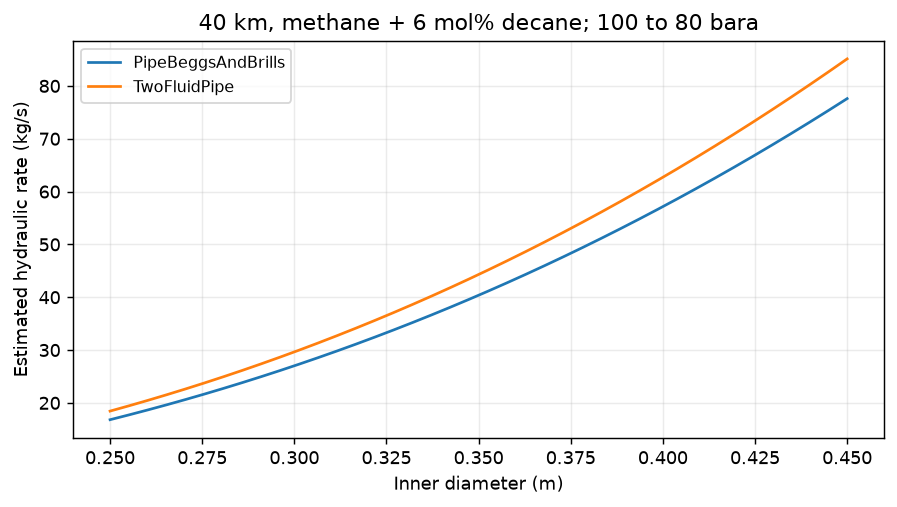

In [11]:
def predict_rate(model_name, design):
    values = np.array([[design[name] for name in feature_names]], dtype=float)
    in_domain = np.isfinite(values).all() and np.all(
        (values[0] >= design_bounds[:, 0]) & (values[0] <= design_bounds[:, 1])
    )
    if not in_domain or not qualified_models[model_name]:
        result, _ = solve_hydraulic_rate(model_name, design)
        return result["rate_kg_s"], "NEQSIM_FALLBACK"
    bundle = surrogate_models[model_name]
    features = bundle["polynomial"].transform(bundle["scaler"].transform(
        pd.DataFrame(values, columns=feature_names)
    ))
    predicted = hydraulic_scaling(values)[0] * np.exp(
        bundle["physical"].predict(features)[0]
    )
    assert np.isfinite(predicted) and predicted > 0.0
    return float(predicted), "SURROGATE_ESTIMATE"

replay_rows = []
for model_name in model_names[:2]:
    for case_label, design in [
        ("inside domain", base_design),
        ("outside domain", {**base_design, "diameter_m": 0.48}),
    ]:
        estimated_rate, route = predict_rate(model_name, design)
        replay, _ = evaluate_pipe(model_name, design, estimated_rate)
        replay_rows.append({
            "model": model_name,
            "case": case_label,
            "route": route,
            "estimated_rate_kg_s": estimated_rate,
            "replayed_outlet_bara": replay["outlet_bara"],
            "receiving_pressure_margin_bar": replay["outlet_bara"] - receiver_pressure_bara,
        })
display(pd.DataFrame(replay_rows).round(5))
assert all(
    row["route"] == "NEQSIM_FALLBACK" for row in replay_rows if row["case"] == "outside domain"
)

figure, axis = plt.subplots(figsize=(7, 4))
diameters = np.linspace(0.25, 0.45, 40)
for model_name in model_names[:2]:
    rates = [
        predict_rate(model_name, {**base_design, "diameter_m": diameter})[0]
        for diameter in diameters
    ]
    axis.plot(diameters, rates, label=model_name)
axis.set(
    xlabel="Inner diameter (m)",
    ylabel="Estimated hydraulic rate (kg/s)",
    title="40 km, methane + 6 mol% decane; 100 to 80 bara",
)
axis.grid(alpha=0.25)
axis.legend(fontsize=9)
figure.tight_layout()
plt.show()

In [12]:
design_trends = []
for model_name in model_names[:2]:
    for diameter in [0.30, 0.35, 0.40]:
        row, _ = solve_hydraulic_rate(model_name, {**base_design, "diameter_m": diameter})
        design_trends.append(row)
    for length_km in [30.0, 40.0, 50.0]:
        row, _ = solve_hydraulic_rate(model_name, {**base_design, "length_km": length_km})
        design_trends.append(row)
trend_frame = pd.DataFrame(design_trends)
for model_name in model_names[:2]:
    selected = trend_frame[trend_frame["model"] == model_name]
    assert np.all(np.diff(selected.iloc[:3]["rate_kg_s"]) > 0.0)
    assert np.all(np.diff(selected.iloc[3:]["rate_kg_s"]) < 0.0)
display(trend_frame[["model", "diameter_m", "length_km", "rate_kg_s"]].round(5))
print("Larger diameter increases rate; longer line decreases rate in the checked cases.")

Larger diameter increases rate; longer line decreases rate in the checked cases.


,model,diameter_m,length_km,rate_kg_s
0,PipeBeggsAndBrills,0.30,40.0,27.04290
1,PipeBeggsAndBrills,0.35,40.0,40.38349
2,PipeBeggsAndBrills,0.40,40.0,57.14061
3,PipeBeggsAndBrills,0.35,30.0,46.45079
4,PipeBeggsAndBrills,0.35,40.0,40.38349
5,PipeBeggsAndBrills,0.35,50.0,36.21345
6,TwoFluidPipe,0.30,40.0,29.47952
7,TwoFluidPipe,0.35,40.0,44.04026
8,TwoFluidPipe,0.40,40.0,62.33856
9,TwoFluidPipe,0.35,30.0,50.90614


## 8. A verified NeqSim improvement: silent flow-solve exhaustion

[Issue #4258](https://github.com/equinor/neqsim/issues/4258) records a library
defect found during this notebook. Beggs–Brill's built-in flow mode returns
normally after its iteration budget is exhausted, without exposing a
convergence report. The minimal synthetic case below deliberately limits
the budget to one iteration. The default pressure tolerance permits
0.008 bar at 80 bara, but the returned result exceeds it.

This is a **controlled expected failure**. It is excluded from all training,
test and design conclusions. The validated outer solver above independently
checks its pressure residual after final replay.

In [13]:
defect_inlet = make_inlet(0.06, 10.0)
defect_pipe = build_pipe("PipeBeggsAndBrills", defect_inlet, base_design)
defect_pipe.setOutletPressure(receiver_pressure_bara, "bara")
defect_pipe.setMaxFlowIterations(1)
defect_pipe.run()
defect_pressure_bara = float(defect_pipe.getOutletStream().getPressure("bara"))
native_relative_tolerance = 1e-4
native_allowed_error_bar = receiver_pressure_bara * native_relative_tolerance
observed_error_bar = defect_pressure_bara - receiver_pressure_bara
defect_evidence = pd.DataFrame([{
    "target_bara": receiver_pressure_bara,
    "returned_bara": defect_pressure_bara,
    "residual_bar": observed_error_bar,
    "allowed_error_bar": native_allowed_error_bar,
    "returned_rate_kg_s": defect_inlet.getFlowRate("kg/sec"),
    "run_returned_normally": True,
}])
display(defect_evidence.round(8))
assert abs(observed_error_bar) > native_allowed_error_bar
print("Expected defect reproduced. This candidate is rejected, never a capacity result.")

Expected defect reproduced. This candidate is rejected, never a capacity result.


,target_bara,returned_bara,residual_bar,allowed_error_bar,returned_rate_kg_s,run_returned_normally
0,80.0,80.43722,0.43722,0.008,40.000139,True


## 9. Improvement priorities and acceptance evidence

| Priority | Finding / improvement | NeqSim tracking and acceptance |
|---|---|---|
| P1 | Native Beggs–Brill flow-solve termination must be explicit and fail closed. | [#4258](https://github.com/equinor/neqsim/issues/4258): add residuals, bracket, iterations and termination reason; test iteration exhaustion, inner errors and restoration. |
| P1 | Model disagreement needs a redistributable experimental pressure-drop/holdup basis. | [#2907](https://github.com/equinor/neqsim/issues/2907), public-validation workstream, and [#4253](https://github.com/equinor/neqsim/issues/4253): ingest traceable cases with uncertainty, units, geometry and fluid provenance; compare both models without tuning to one trace. |
| P2 | Network/design results should carry common model, unit, convergence and validity evidence. | [#4228](https://github.com/equinor/neqsim/issues/4228): reuse existing pipe adapters and surrogate registry; retain exact revision, phase basis, thermal/terrain assumptions and replay evidence. |
| P2 | Real subsea-to-shore operability needs thermal, terrain and transient qualification. | [#3298](https://github.com/equinor/neqsim/issues/3298) and [#2907](https://github.com/equinor/neqsim/issues/2907): establish mesh/time convergence, phase conservation, liquid accumulation and sustained-slug benchmarks before making operational claims. |

Numerical limits and response-surface accuracy above are measured notebook
findings. The latter three items are engineering follow-ups under existing
roadmaps; this study does not establish an additional library defect for them.
Do not create duplicate implementations or infer transient qualification
from a successful steady calculation.

## 10. Add a published dataset without confusing its meaning

The adapter below distinguishes a measurement from an independent-simulator
output and checks required units/provenance. Supply one row per reported
measurement at a **specified mass rate**, rather than silently solving a
different rate. The current runner supports only this notebook's binary,
horizontal, isothermal setup. Other fluids, elevations and heat-transfer
conditions must be implemented before their data can be evaluated.

Required columns include DOI/URL, reuse permission, temperature and absolute
pressure basis, uncertainty, geometry, composition and rate. Experimental
uncertainty is reported as one standard deviation in bar. Do not fill
missing observations or uncertainties with simulator predictions.

In [14]:
benchmark_columns = [
    "source_url", "reuse_permission", "evidence_kind", "diameter_m", "length_km",
    "decane_mol_fraction", "rate_kg_s", "inlet_bara", "temperature_c",
    "roughness_m", "elevation_change_m", "thermal_mode",
    "observed_outlet_bara", "standard_uncertainty_bar",
]
benchmark_template = pd.DataFrame(columns=benchmark_columns)
display(pd.DataFrame({
    "required CSV field": benchmark_columns,
    "purpose": [
        "Source URL / DOI", "Reuse permission or license",
        "measurement or independent_simulator", "Inner diameter, m",
        "Line length, km", "Decane mole fraction", "Mass rate, kg/s",
        "Absolute inlet pressure, bara", "Isothermal temperature, Celsius",
        "Absolute roughness, m", "Net elevation change, m",
        "Must be isothermal for this adapter", "Observed outlet pressure, bara",
        "One-standard-deviation uncertainty, bar",
    ],
}))

def compare_public_cases(data):
    missing = set(benchmark_columns) - set(data.columns)
    if missing:
        raise ValueError(f"Missing benchmark columns: {sorted(missing)}")
    if data.empty:
        raise ValueError("No public numerical observations have been supplied.")
    records = []
    for _, observation in data.iterrows():
        assert str(observation["source_url"]).startswith("https://")
        assert str(observation["reuse_permission"]).strip()
        assert observation["evidence_kind"] in ["measurement", "independent_simulator"]
        assert observation["thermal_mode"] == "isothermal"
        assert observation["elevation_change_m"] == 0.0
        assert observation["inlet_bara"] == inlet_pressure_bara
        assert observation["temperature_c"] == inlet_temperature_c
        assert observation["roughness_m"] == roughness_m
        assert observation["standard_uncertainty_bar"] > 0.0
        design = {name: float(observation[name]) for name in feature_names}
        for model_name in model_names[:2]:
            calculated, _ = evaluate_pipe(model_name, design, observation["rate_kg_s"])
            residual = calculated["outlet_bara"] - observation["observed_outlet_bara"]
            records.append({
                "source_url": observation["source_url"],
                "evidence_kind": observation["evidence_kind"],
                "model": model_name,
                "prediction_bara": calculated["outlet_bara"],
                "observed_bara": observation["observed_outlet_bara"],
                "residual_bar": residual,
                "residual_in_standard_uncertainties": residual
                / observation["standard_uncertainty_bar"],
            })
    return pd.DataFrame(records)

try:
    compare_public_cases(benchmark_template)
except ValueError as error:
    print("Empty-data guard passed:", str(error))
else:
    raise AssertionError("Empty benchmark data must never be presented as validation.")

Empty-data guard passed: No public numerical observations have been supplied.


,required CSV field,purpose
0,source_url,Source URL / DOI
1,reuse_permission,Reuse permission or license
2,evidence_kind,measurement or independent_simulator
3,diameter_m,"Inner diameter, m"
4,length_km,"Line length, km"
5,decane_mol_fraction,Decane mole fraction
6,rate_kg_s,"Mass rate, kg/s"
7,inlet_bara,"Absolute inlet pressure, bara"
8,temperature_c,"Isothermal temperature, Celsius"
9,roughness_m,"Absolute roughness, m"


## 11. Results, reproducibility and limitations

Results are summarized from the executed cells below. The analytical limit,
mass closure, pressure-root residual, mesh sensitivity and trend checks are
explicit. Sixteen off-grid cases assess approximation to each simulator,
rather than accuracy against measurements. Model disagreement, finite mesh
effects, surrogate error and experimental uncertainty are different quantities.

On the pinned source, the 40 km, 0.35 m, 6 mol% decane baseline gives
**40.38 kg/s** with Beggs–Brill and **44.04 kg/s** with TwoFluidPipe.
The homogeneous diagnostic gives 63.70 kg/s, demonstrating why it should
not replace a slip/holdup calculation for this two-phase design.
Across the design cases, TwoFluidPipe rates exceed Beggs–Brill by up to
16.15%. No experimental basis here decides which rate is more accurate.

The physics-informed surrogate reduces the worst held-out rate difference
from 11.65% to 0.52% for Beggs–Brill and from 15.04% to 2.17% for
TwoFluidPipe. This supports bounded screening and simulator replay;
it does not reduce the underlying model disagreement.

The files exported below contain all 86 hydraulic roots, coefficients,
held-out predictions, model differences, checks and source/dependency
provenance. They complement the inline outputs, which remain in this notebook.
The notebook was inspected through Jupyter HTML and locally rendered MathJax
SVG; validation evidence is recorded in the companion maintenance ledger.

Hosted Colab downloads/source compilation are a setup route. Local validation
uses the same exact source-built JAR and a fresh Python process; the hosted
download route has not been exercised here.

**Exercises:** add a sourced experimental dataset; extend the fluid basis
to a characterized reservoir fluid; add explicit heat transfer and shore
elevation; compare design points with two-phase regime changes; repeat
the 30-to-60 section check at design-box corners before using the entire
surrogate as a design tool.

In [15]:
checks = {
    "source_and_class_location_verified": True,
    "86_converged_hydraulic_roots": len(sweep) == 86 and bool(sweep["converged"].all()),
    "receiving_pressure_residual_qualified": bool(
        sweep["pressure_residual_bar"].abs().max() <= pressure_tolerance_bar
    ),
    "mass_balance_qualified": bool(sweep["mass_balance_relative"].max() < 1e-9),
    "single_liquid_Darcy_limit_within_15pct": bool(
        (analytical["relative_difference_pct"].abs() < 15.0).all()
    ),
    "baseline_30_to_60_mesh_rate_within_3pct": bool(
        (nominal_mesh["rate_difference_from_60_pct"].abs() < 3.0).all()
    ),
    "all_surrogate_predictions_positive": bool(
        (metrics["minimum_prediction_kg_s"] > 0.0).all()
    ),
    "out_of_domain_fallback_verified": True,
    "native_flow_iteration_defect_reproduced": bool(
        abs(observed_error_bar) > native_allowed_error_bar
    ),
    "no_experimental_accuracy_claim": True,
}
assert all(checks.values())
display(pd.DataFrame([{"check": name, "passed": passed} for name, passed in checks.items()]))
summary = {
    "baseline_rates_kg_s": dict(zip(baseline["model"], baseline["rate_kg_s"])),
    "max_model_rate_difference_pct": float(paired["TwoFluid_minus_BB_pct"].abs().max()),
    "held_out_metrics": metrics.to_dict(orient="records"),
    "surrogate_screening_qualification": qualified_models,
    "validation_checks": checks,
    "evidence": "synthetic simulation, analytical hydraulic limit and numerical checks",
    "experimental_validation": False,
    "related_issues": [4253, 4258, 2907, 4228, 3298],
    "provenance": provenance,
}
print(json.dumps(summary, indent=2))
output_directory = Path("subsea_to_shore_4253_results")
output_directory.mkdir(exist_ok=True)
for filename, frame in [
    ("hydraulic_roots.csv", sweep),
    ("held_out_predictions.csv", predictions),
    ("coefficients.csv", coefficients),
    ("model_disagreement.csv", paired),
    ("mesh_refinement.csv", mesh),
    ("public_benchmark_template.csv", benchmark_template),
]:
    frame.to_csv(output_directory / filename, index=False)
(output_directory / "summary.json").write_text(json.dumps(summary, indent=2))
print("Exported files:")
for path in sorted(output_directory.iterdir()):
    print(" -", path.name)

{
  "baseline_rates_kg_s": {
    "PipeBeggsAndBrills": 40.383490984789795,
    "TwoFluidPipe": 44.040257414113945,
    "AdiabaticPipe": 63.70336041052979
  },
  "max_model_rate_difference_pct": 16.15464595296976,
  "held_out_metrics": [
    {
      "model": "PipeBeggsAndBrills",
      "surrogate": "quadratic",
      "MAE_kg_s": 1.2184734077353012,
      "MAPE_pct": 3.8430859028461244,
      "max_relative_error_pct": 11.651558293580367,
      "minimum_prediction_kg_s": 15.134350951513966
    },
    {
      "model": "PipeBeggsAndBrills",
      "surrogate": "physics-informed",
      "MAE_kg_s": 0.09960390773485572,
      "MAPE_pct": 0.21382231758902337,
      "max_relative_error_pct": 0.5219953859960703,
      "minimum_prediction_kg_s": 13.967951244093472
    },
    {
      "model": "TwoFluidPipe",
      "surrogate": "quadratic",
      "MAE_kg_s": 1.6050611641125843,
      "MAPE_pct": 4.766937484878066,
      "max_relative_error_pct": 15.038090643660587,
      "minimum_prediction_kg_s": 1

,check,passed
0,source_and_class_location_verified,True
1,86_converged_hydraulic_roots,True
2,receiving_pressure_residual_qualified,True
3,mass_balance_qualified,True
4,single_liquid_Darcy_limit_within_15pct,True
5,baseline_30_to_60_mesh_rate_within_3pct,True
6,all_surrogate_predictions_positive,True
7,out_of_domain_fallback_verified,True
8,native_flow_iteration_defect_reproduced,True
9,no_experimental_accuracy_claim,True
